An [influence line](https://en.wikipedia.org/wiki/Influence_line) is a graph that shows a response quantity at a fixed point in a structure as a function of a load's location. In this study the response quantity we'll investigate is the axial force in each truss member. 

In [2]:
import xara
from xara.load import NodalLoad
import numpy as np
import veux

## 1) Model

In [ ]:
def create_model():
    model = xara.Model(ndm=2, ndf=2) 
    
    # ------------------------------
    # Geometry parameters
    # ------------------------------
    span = 12.0    # Total length in meters
    num_elem = 11  # Number of elements
    num_node = 7   # Number of node
    node_x_diff= span/(num_node-1)
    
    # ------------------------------
    # Material properties
    # ------------------------------
    # Material & section for W14x38
    E  = 210e9  # Young's modulus in Pascals (steel)
    A1 = 0.00723     # Cross-sectional area in m^2
    Fy = 340e6
    model.uniaxialMaterial("Steel02", 1, Fy, E, 0.02)
    
    # Material & section for HSS10x10x1/2
    A2 = 0.00645  # Cross-sectional area in m^2
    model.uniaxialMaterial("Steel02", 2, Fy, E, 0.02)

    model.section("Truss", 1, area=A1, material=1)
    model.section("Truss", 2, area=A2, material=2)
    
    # ------------------------------
    # Define nodes
    # ------------------------------
    for i in range(1, num_node+1):
        if i <= 4: 
            model.node(i ,((i-1)*node_x_diff*2,0))
        elif i>4:
            model.node(i ,(4*(i-5)+node_x_diff,node_x_diff))

    
    # ------------------------------
    # Define boundary conditions
    # ------------------------------
    model.fix(1, (1, 1))  # Pin at node 1
    model.fix(4, (0, 1))  # Roller at node 4
    
    # ------------------------------
    # Define truss elements
    # ------------------------------
    for i in range(1,num_elem+1):
        if i <=3:
            # Beam: W14x38 between nodes 1 and 2
            model.element("Truss", i, (i, i+1), section=1)
        elif i <=5:
            # Beam: HSS10x10x1/2 between node 5 and 6
            model.element("Truss", i, (i+1, i+2), section=2)
        elif i <=8:
            # Beam: HSS10x10x1/2 between node 1 and 5
            model.element("Truss", i, (i-5, i-1), section=2)
        elif i <=11:
            # Beam: HSS10x10x1/2 between node 2 and 5
            model.element("Truss", i, (i-4, i-7), section=2)
    return model

model = create_model()
veux.render(model)

## 2) Loading

In [ ]:
def create_load(model, load, loc):
    "Add loading to a the model"

    for node in range(1, 4+1):
        if model.nodeCoord(node)[0] > loc:
            break

    right_node = node
    left_node = node-1
    L = 4
    a = loc - model.nodeCoord(left_node)[0]

    return NodalLoad({
        left_node: (0,  (4-a)/4*load),
        right_node: (0, a/4*load)
    })

In [ ]:
 
def analyze(model, load, steps=1):
    # ------------------------------
    # Run analysis 
    # ------------------------------
    xara.solve(model, load)
    
    # ------------------------------
    # Collect outputs
    # ------------------------------
    u, p = [], []
    for i in range(steps):
        # model.analyze(1)
        p.append(model.getTime())
        u.append(model.nodeDisp(6, 2))

    return u, p

## 3) Analysis

To construct the influence lines, we'll begin by initializing a *dictionary* that holds empty lists for the influence lines corresponding to each member:

In [6]:
forces = {i: {"x": [], "force": []} for i in create_model().getEleTags()}

In [7]:

for x in np.linspace(0, 12, 10):
    model = create_model()
    loads = create_load(model, 1.0, x)
    analyze(model, loads)

    for elem in model.getEleTags():
        forces[elem]["x"].append(x)
        forces[elem]["force"].append(model.eleResponse(elem, "basicForce"))
    



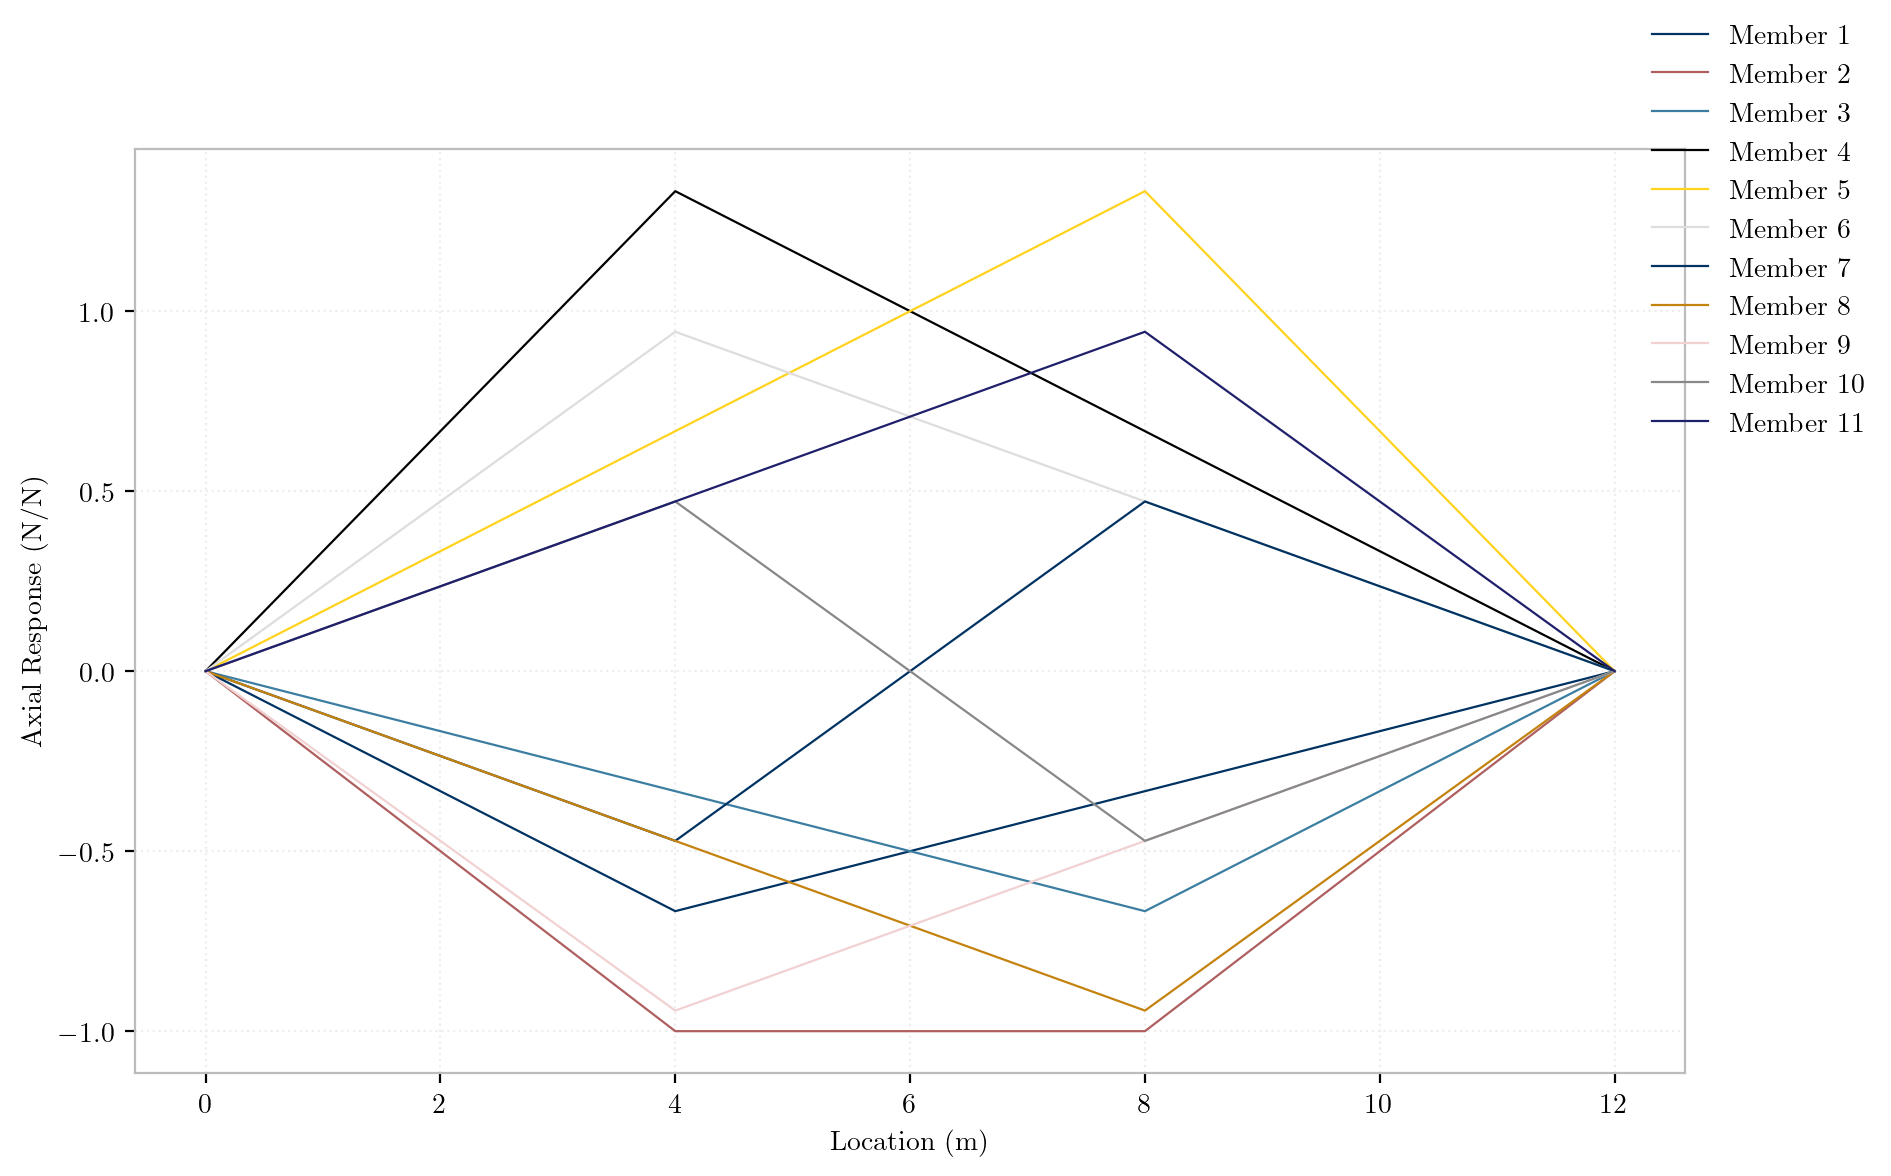

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("veux-web")

fig, ax = plt.subplots(figsize=(10, 6))

for elem in range(1, 12):
    ax.plot(forces[elem]["x"], forces[elem]["force"], label=f"Member {elem}")

ax.set_xlabel("Location (m)")
ax.set_ylabel("Axial Response (N/N)")
fig.legend();